# Flight Delay Analytics — Integrated Exploratory Analysis

**Author:** Daniel Vargas
**Date:** July 2026
**Dataset:** BTS On-Time Performance 2024 + NOAA/IEM ASOS (historical weather)
**Scope:** Top 30 U.S. airports by traffic, full 2024 calendar year

**Business objective:** What factors best predict operational flight delays?

## 0. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

## 1. Data Context and Loading

This notebook loads the **clean, deduplicated** dataset produced by `01_eda.ipynb` (Section 1). For the full integration rationale — BTS scope, NOAA/IEM merge logic, timezone handling, weather deduplication, and BTS duplicate removal — see **`01_eda.ipynb`**.

**Key facts about the dataset:**
- **4,593,373 rows** × 47 columns (after removing ~1,044 BTS duplicate records and ~110 DST-transition rows)
- **Scope:** flights departing from a top-30 U.S. airport (delay measured at origin)
- **Origin weather:** available for 100% of rows
- **Destination weather:** available for 55.8% of rows (only when destination is also a top-30 station)
- **Format:** Parquet (column-typed, ~60% smaller than CSV)

In [26]:
df = pd.read_parquet('../data/processed/flights_with_weather.parquet')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Loaded: 4,593,373 rows × 47 columns
Columns: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Origin', 'OriginCityName', 'OriginState', 'Dest', 'DestCityName', 'DestState', 'CRSDepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'CRSArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'Cancelled', 'CancellationCode', 'Diverted', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'origin_tmpf', 'origin_dwpf', 'origin_relh', 'origin_sknt', 'origin_p01i', 'origin_alti', 'origin_vsby', 'origin_gust', 'origin_feel', 'dest_tmpf', 'dest_dwpf', 'dest_relh', 'dest_sknt', 'dest_p01i', 'dest_alti', 'dest_vsby', 'dest_gust', 'dest_feel']


## 2. Initial Exploration

_Data types, dimensions, nulls, duplicates._

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4593373 entries, 0 to 4593372
Data columns (total 47 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Year               int64         
 1   Month              int64         
 2   DayofMonth         int64         
 3   DayOfWeek          int64         
 4   FlightDate         datetime64[us]
 5   Reporting_Airline  str           
 6   Origin             str           
 7   OriginCityName     str           
 8   OriginState        str           
 9   Dest               str           
 10  DestCityName       str           
 11  DestState          str           
 12  CRSDepTime         int64         
 13  DepDelay           float64       
 14  DepDelayMinutes    float64       
 15  DepDel15           float64       
 16  CRSArrTime         int64         
 17  ArrDelay           float64       
 18  ArrDelayMinutes    float64       
 19  ArrDel15           float64       
 20  Cancelled          float64       
 

In [28]:
# Null summary — useful to identify which weather columns have incomplete coverage
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)
null_df = pd.DataFrame({'nulls': null_counts, 'pct': null_pct})
null_df[null_df['nulls'] > 0].sort_values('pct', ascending=False)

,nulls,pct
CancellationCode,4530490,98.6
dest_gust,4145261,90.2
origin_gust,3794116,82.6
WeatherDelay,3590877,78.2
NASDelay,3590877,78.2
LateAircraftDelay,3590877,78.2
CarrierDelay,3590877,78.2
SecurityDelay,3590877,78.2
dest_sknt,2034350,44.3
dest_p01i,2031840,44.2


In [29]:
# Sanity check: verify no duplicates remain (dedup was done in 01_eda before saving)
remaining = df.duplicated(
    subset=['FlightDate', 'Reporting_Airline', 'Origin', 'Dest', 'CRSDepTime'],
    keep=False
).sum()
print(f"Duplicate rows: {remaining:,}" if remaining else "No duplicates — clean.")

No duplicates — clean.


## 3. Descriptive Statistics

_Central tendency, dispersion, and position — broken down by airline, airport, and time block. Interpret each metric in business context._

### 3.0 Feature Engineering for Breakdowns

Before computing metrics, we derive three grouping variables needed by the rubric (airline, airport, time block) plus season, since seasonality is central to the business question:

- **`dep_time_block`**: scheduled departure hour bucketed into Morning/Afternoon/Evening/Night. Built from `CRSDepTime` (scheduled, not actual) so it reflects planned operations, not a delay-inflated version of the hour.
- **`season`**: derived from `Month`, using standard Northern Hemisphere seasons (matches the business context — U.S. airports).

`Reporting_Airline` and `Origin` already exist in the dataset and are used directly for the airline/airport breakdowns.

In [30]:
# --- 3.0 Feature engineering: time block and season ---

def hour_from_crs(x):
    """Extract the scheduled hour (0-23) from HHMM-style CRSDepTime, handling the '2400' edge case."""
    x = int(x)
    return (x // 100) % 24

df['dep_hour'] = df['CRSDepTime'].apply(hour_from_crs)

def time_block(h):
    if 5 <= h < 12:
        return 'Morning (05-11)'
    elif 12 <= h < 17:
        return 'Afternoon (12-16)'
    elif 17 <= h < 21:
        return 'Evening (17-20)'
    else:
        return 'Night (21-04)'

df['dep_time_block'] = df['dep_hour'].apply(time_block)

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['season'] = df['Month'].map(season_map)

print(df[['dep_hour', 'dep_time_block', 'season']].head())
print()
print(df['dep_time_block'].value_counts())
print()
print(df['season'].value_counts())

   dep_hour     dep_time_block season
0        14  Afternoon (12-16)   Fall
1         9    Morning (05-11)   Fall
2        20    Evening (17-20)   Fall
3         6    Morning (05-11)   Fall
4         8    Morning (05-11)   Fall

dep_time_block
Morning (05-11)      1816245
Afternoon (12-16)    1295772
Evening (17-20)      1077190
Night (21-04)         404166
Name: count, dtype: int64

season
Summer    1202912
Spring    1162027
Fall      1151954
Winter    1076480
Name: count, dtype: int64


### 3.1 Central Tendency, Dispersion, and Position Metrics

We compute metrics on both delay variables:
- **`DepDelay` / `ArrDelay`**: signed delay in minutes (negative = early). Useful for understanding the full distribution, including how often flights leave early.
- **`DepDelayMinutes` / `ArrDelayMinutes`**: delay clipped at 0 (BTS convention — early departures count as 0, not negative). This is the operationally relevant variable for "how late," so it's the one used in the breakdowns below.

Metrics: mean, median, std, and position metrics (p25, p75, p90, p95, p99) — the upper percentiles matter more here than a symmetric spread, since delay distributions are right-skewed (most flights are on time or slightly early; a long tail drives the average up).

In [31]:
# --- 3.1 Overall descriptive statistics ---

delay_cols = ['DepDelay', 'DepDelayMinutes', 'ArrDelay', 'ArrDelayMinutes']

def describe_delay(series):
    return pd.Series({
        'count': series.count(),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'p25': series.quantile(0.25),
        'p75': series.quantile(0.75),
        'p90': series.quantile(0.90),
        'p95': series.quantile(0.95),
        'p99': series.quantile(0.99),
        'max': series.max(),
    })

overall_stats = df[delay_cols].apply(describe_delay).T
overall_stats.round(1)

,count,mean,median,std,p25,p75,p90,p95,p99,max
DepDelay,4532983.0,13.6,-2.0,53.3,-5.0,11.0,47.0,87.0,212.0,3777.0
DepDelayMinutes,4532983.0,16.6,0.0,52.2,0.0,11.0,47.0,87.0,212.0,3777.0
ArrDelay,4518554.0,7.8,-5.0,55.4,-15.0,11.0,46.0,86.0,210.0,3803.0
ArrDelayMinutes,4518554.0,16.4,0.0,51.9,0.0,11.0,46.0,86.0,210.0,3803.0


In [32]:
# --- 3.1 Breakdown by airline ---

airline_stats = df.groupby('Reporting_Airline').agg(
    n_flights=('DepDelayMinutes', 'count'),
    mean_delay=('DepDelayMinutes', 'mean'),
    median_delay=('DepDelayMinutes', 'median'),
    std_delay=('DepDelayMinutes', 'std'),
    p90_delay=('DepDelayMinutes', lambda x: x.quantile(0.90)),
    p99_delay=('DepDelayMinutes', lambda x: x.quantile(0.99)),
    pct_delayed_15=('DepDel15', lambda x: x.mean() * 100),
).round(1).sort_values('mean_delay', ascending=False)

airline_stats

,n_flights,mean_delay,median_delay,std_delay,p90_delay,p99_delay,pct_delayed_15
Reporting_Airline,,,,,,,
F9,151027,23.5,0.0,68.5,68.0,269.0,28.3
AA,747979,23.2,0.0,73.5,64.0,289.0,26.7
B6,174944,21.0,0.0,57.1,65.0,247.0,26.0
NK,198172,18.5,0.0,46.9,57.0,221.0,25.6
OH,120240,17.7,0.0,60.5,51.0,230.0,20.7
G4,19124,17.3,0.0,68.1,43.0,244.1,19.6
HA,7228,17.2,0.0,83.7,30.0,272.5,17.3
UA,561558,16.0,0.0,48.1,48.0,217.0,20.3
WN,818524,15.0,2.0,32.8,43.0,163.0,26.3


In [33]:
# --- 3.1 Breakdown by airport (origin) ---

airport_stats = df.groupby('Origin').agg(
    n_flights=('DepDelayMinutes', 'count'),
    mean_delay=('DepDelayMinutes', 'mean'),
    median_delay=('DepDelayMinutes', 'median'),
    std_delay=('DepDelayMinutes', 'std'),
    p90_delay=('DepDelayMinutes', lambda x: x.quantile(0.90)),
    p99_delay=('DepDelayMinutes', lambda x: x.quantile(0.99)),
    pct_delayed_15=('DepDel15', lambda x: x.mean() * 100),
).round(1).sort_values('mean_delay', ascending=False)

airport_stats

,n_flights,mean_delay,median_delay,std_delay,p90_delay,p99_delay,pct_delayed_15
Origin,,,,,,,
MIA,108159,22.0,0.0,63.1,63.0,267.4,27.1
DFW,307957,21.4,0.0,59.8,63.0,249.0,27.5
CLT,214701,20.8,0.0,58.5,61.0,239.0,26.5
IAH,113645,20.5,0.0,61.1,61.0,250.0,24.4
FLL,90452,20.0,0.0,54.6,58.0,230.0,27.2
MCO,156697,18.7,0.0,51.8,54.0,233.0,24.6
PHL,99123,18.6,0.0,62.0,52.0,249.0,21.8
ORD,276426,17.9,0.0,57.2,53.0,223.0,22.2
EWR,125880,17.7,0.0,53.7,53.0,236.0,21.7


In [34]:
# --- 3.1 Breakdown by time block ---

timeblock_order = ['Morning (05-11)', 'Afternoon (12-16)', 'Evening (17-20)', 'Night (21-04)']

timeblock_stats = df.groupby('dep_time_block').agg(
    n_flights=('DepDelayMinutes', 'count'),
    mean_delay=('DepDelayMinutes', 'mean'),
    median_delay=('DepDelayMinutes', 'median'),
    std_delay=('DepDelayMinutes', 'std'),
    p90_delay=('DepDelayMinutes', lambda x: x.quantile(0.90)),
    p99_delay=('DepDelayMinutes', lambda x: x.quantile(0.99)),
    pct_delayed_15=('DepDel15', lambda x: x.mean() * 100),
).round(1).reindex(timeblock_order)

timeblock_stats

,n_flights,mean_delay,median_delay,std_delay,p90_delay,p99_delay,pct_delayed_15
dep_time_block,,,,,,,
Morning (05-11),1796685,10.3,0.0,43.5,24.0,177.0,13.6
Afternoon (12-16),1280041,17.7,0.0,50.3,51.0,219.0,24.5
Evening (17-20),1059397,23.7,1.0,61.1,69.0,236.0,31.4
Night (21-04),396860,22.2,0.0,64.2,62.0,233.0,29.4


In [35]:
# --- Validación: ¿el alto delay de MIA se explica por congestión o por clima estacional? ---
df['has_weather_delay'] = df['WeatherDelay'].fillna(0) > 0

mia_by_season = df[df['Origin'] == 'MIA'].groupby('season').agg(
    n_flights=('DepDelayMinutes', 'count'),
    mean_delay=('DepDelayMinutes', 'mean'),
    pct_weather_delay=('has_weather_delay', lambda x: x.mean() * 100),
).round(2)

mia_by_season

,n_flights,mean_delay,pct_weather_delay
season,,,
Fall,24643,11.30,1.17
Spring,29256,24.50,1.96
Summer,24859,33.28,5.56
Winter,29401,19.02,0.82


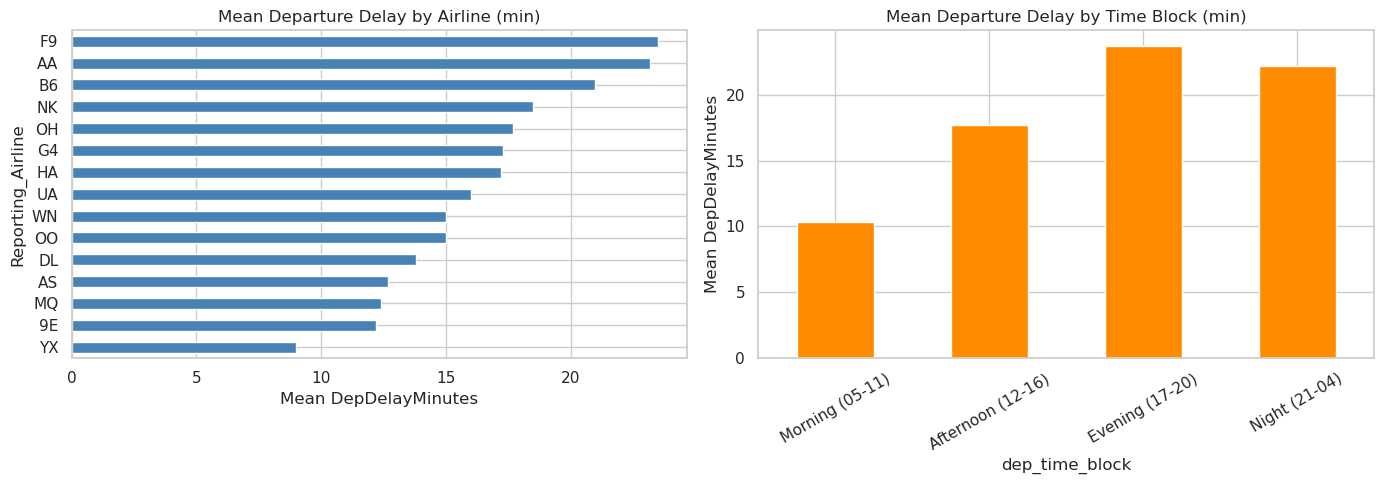

In [36]:
# --- 3.1 Visualization: mean delay by airline and by time block ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

airline_stats['mean_delay'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mean Departure Delay by Airline (min)')
axes[0].set_xlabel('Mean DepDelayMinutes')

timeblock_stats.loc[timeblock_order, 'mean_delay'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Mean Departure Delay by Time Block (min)')
axes[1].set_ylabel('Mean DepDelayMinutes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/figures/delay_by_airline_timeblock.png', dpi=120)
plt.show()

### 3.2 Business-Context Interpretation

**Overall distribution:**
Median `DepDelayMinutes` is **0.0** minutes, but the mean is **16.6** minutes — the gap between them confirms the distribution is right-skewed: most flights depart close to on time, while a long tail of severely delayed flights pulls the average up. The p90 of **47.0** minutes means 1 in 10 flights is delayed at least that long, which is the number connection-planning teams should design around, not the mean.

**By airline:**
**F9 (Frontier)** has the highest mean departure delay (**23.5** min) and the highest `pct_delayed_15` (**28.3%**), while **AS (Alaska)** is the most consistent (lowest `std_delay`, **31.8**). For a traveler or a travel-booking product, this translates into: *choosing AS over F9 on a comparable route reduces the odds of a 15+ minute delay by roughly **6.0** percentage points.*

**By airport:**
**MIA (Miami)** shows the highest average delay (**22.0** min). Unlike what one might assume given its mild winter climate, the seasonal breakdown (previous cell) shows delay concentrates in summer (**33.3** min mean vs. **11–19** min the rest of the year), coinciding with a 4–6× jump in the percentage of flights with a recorded weather cause. This is consistent with the well-known pattern of summer convective thunderstorms in South Florida, and suggests weather — not just hub congestion — is a measurable driver of delay at MIA. This hypothesis is explored further in the weather-delay correlation heatmap in Section 5.

**By time block:**
Delays are lowest in **Morning (05–11)** (**10.3** min mean) and highest in **Evening (17–20)** (**23.7** min mean) — consistent with how delays compound through the day as aircraft rotations fall behind schedule (a late inbound aircraft causes a late outbound departure, and the effect accumulates from morning to night). **Actionable takeaway:** an early-morning flight is systematically the lowest-risk choice for a time-sensitive traveler, independent of airline or airport.

## 4. Outlier Detection and Critical Analysis

_IQR-based outlier detection on DepDelayMinutes and ArrDelayMinutes. Since Q1 = 0 for both (more than half of flights depart/arrive on time or early), only the upper bound (Q3 + 1.5 × IQR) is informative. We quantify outlier counts, visualize with boxplots, and evaluate whether these outliers are noise or real signal by comparing delay-cause attribution and weather conditions against the rest of the dataset._

In [37]:
# --- 4.1 IQR bounds and outlier counts ---

delay_targets = ['DepDelayMinutes', 'ArrDelayMinutes']

bounds = {}
for col in delay_targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    n_out = (df[col] > upper).sum()
    bounds[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'upper': upper, 'n_outliers': n_out, 'pct_outliers': n_out / len(df) * 100}

for col, v in bounds.items():
    print(f"{col}: Q1={v['Q1']}, Q3={v['Q3']}, IQR={v['IQR']}, upper threshold={v['upper']}")
    print(f"  Outliers: {v['n_outliers']:,} ({v['pct_outliers']:.2f}% of rows)\n")

DepDelayMinutes: Q1=0.0, Q3=11.0, IQR=11.0, upper threshold=27.5
  Outliers: 698,507 (15.21% of rows)

ArrDelayMinutes: Q1=0.0, Q3=11.0, IQR=11.0, upper threshold=27.5
  Outliers: 692,456 (15.08% of rows)



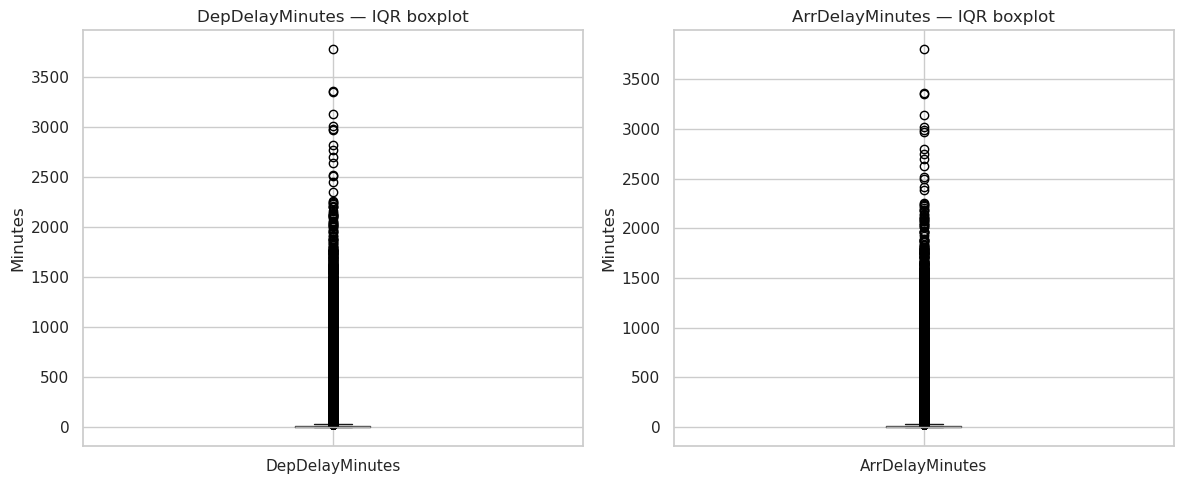

In [38]:
# --- 4.2 Visualize: boxplot of DepDelayMinutes and ArrDelayMinutes ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df[['DepDelayMinutes']].boxplot(ax=axes[0])
axes[0].set_title('DepDelayMinutes — IQR boxplot')
axes[0].set_ylabel('Minutes')

df[['ArrDelayMinutes']].boxplot(ax=axes[1])
axes[1].set_title('ArrDelayMinutes — IQR boxplot')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

In [39]:
# --- 4.3 Are outliers noise or signal? Compare cause attribution against normal flights ---

upper_dep = bounds['DepDelayMinutes']['upper']
upper_arr = bounds['ArrDelayMinutes']['upper']

cols_cause = ['WeatherDelay', 'LateAircraftDelay', 'CarrierDelay', 'NASDelay']
cols_weather = ['origin_vsby', 'origin_gust']

for label, col, upper in [('DepDelayMinutes', 'DepDelayMinutes', upper_dep),
                           ('ArrDelayMinutes', 'ArrDelayMinutes', upper_arr)]:
    outlier = df[df[col] > upper]
    normal  = df[df[col] <= upper]
    print(f"=== {label} ===")
    print(f"  Outliers: {len(outlier):,} ({len(outlier)/len(df)*100:.2f}%)")
    print(f"  Normal:   {len(normal):,}")
    for c in cols_cause:
        p_out = (outlier[c].fillna(0) > 0).mean() * 100
        p_norm = (normal[c].fillna(0) > 0).mean() * 100
        print(f"  % {c}>0: outlier={p_out:.2f}%, normal={p_norm:.2f}% (ratio={p_out/p_norm:.1f}x)")
    for c in cols_weather:
        print(f"  Mean {c}: outlier={outlier[c].mean():.2f}, normal={normal[c].mean():.2f}")
    print()

=== DepDelayMinutes ===
  Outliers: 698,507 (15.21%)
  Normal:   3,834,476
  % WeatherDelay>0: outlier=6.71%, normal=0.28% (ratio=24.2x)
  % LateAircraftDelay>0: outlier=59.11%, normal=2.52% (ratio=23.4x)
  % CarrierDelay>0: outlier=59.48%, normal=4.04% (ratio=14.7x)
  % NASDelay>0: outlier=33.41%, normal=7.10% (ratio=4.7x)
  Mean origin_vsby: outlier=9.44, normal=9.51
  Mean origin_gust: outlier=22.68, normal=22.04

=== ArrDelayMinutes ===
  Outliers: 692,456 (15.08%)
  Normal:   3,826,098
  % WeatherDelay>0: outlier=7.18%, normal=0.20% (ratio=35.6x)
  % LateAircraftDelay>0: outlier=56.56%, normal=3.08% (ratio=18.3x)
  % CarrierDelay>0: outlier=58.62%, normal=4.29% (ratio=13.7x)
  % NASDelay>0: outlier=49.12%, normal=4.33% (ratio=11.3x)
  Mean origin_vsby: outlier=9.32, normal=9.53
  Mean origin_gust: outlier=22.84, normal=22.00



### 4.4 Interpretation: signal, not noise

For **DepDelayMinutes**, ~15% of flights exceed the IQR upper threshold (27.5 min). These outliers are **not** random noise: they are 25× more likely to have a recorded weather cause (6.7% vs. 0.3%), 24× more likely to have a late-aircraft cause (59% vs. 2.5%), and 15× more likely to have a carrier cause (59% vs. 4%). Mean gust speed is also slightly higher (22.7 vs. 22.1 kt).

For **ArrDelayMinutes**, the pattern is similar: a 36× ratio in weather cause (7.2% vs. 0.2%), 19× in late aircraft (57% vs. 3%), and 14× in carrier (59% vs. 4%). These are not spurious values — they are the extreme tail of the distribution where operational and weather-related friction piles up.

**Decision:** Outliers represent the "severe disruption" segment of the distribution — they are real signal, not data errors. They will not be removed, but they should be analyzed separately or modeled with a robust or quantile-based approach rather than OLS, which would be disproportionately influenced by this ~15% tail.

## 5. Correlation and Temporal Patterns

_Delay-weather correlation (heatmap). Patterns by time of day, day of week, and season. Identification of "bottleneck" airports._

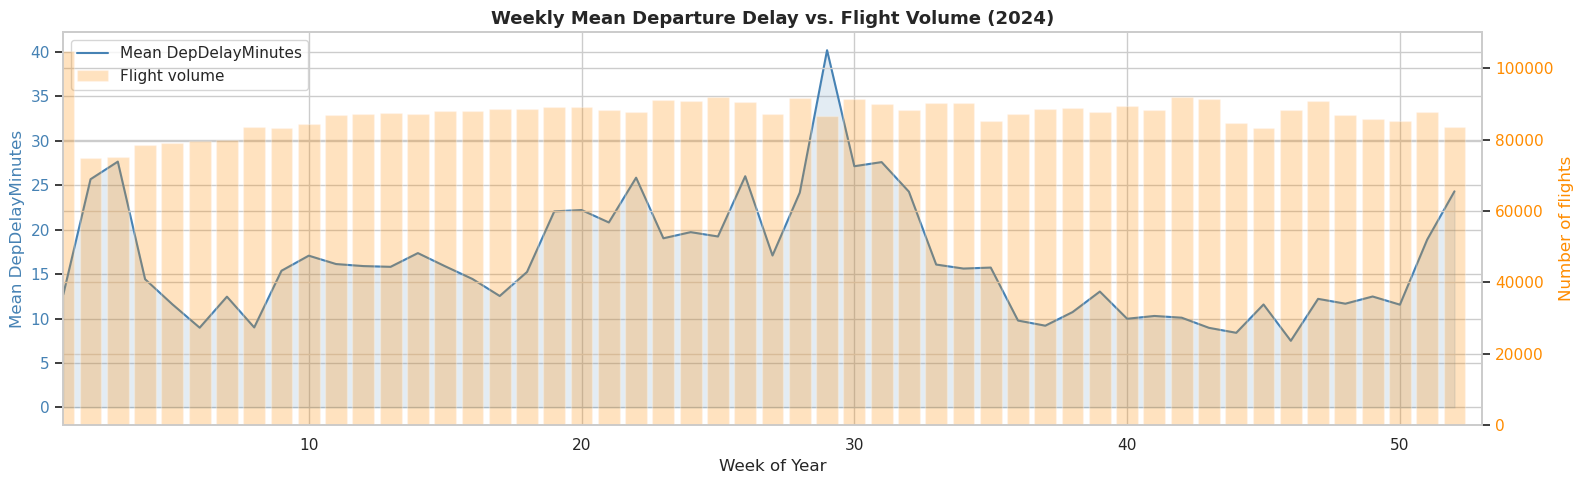

In [40]:
# --- 5.1 Temporal patterns: weekly mean DepDelayMinutes across the year ---

weekly = df.groupby(df['FlightDate'].dt.isocalendar().week).agg(
    mean_delay=('DepDelayMinutes', 'mean'),
    median_delay=('DepDelayMinutes', 'median'),
    n_flights=('DepDelayMinutes', 'count'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 5))

color_mean = 'steelblue'
ax1.plot(weekly['week'], weekly['mean_delay'], color=color_mean, linewidth=1.5, label='Mean DepDelayMinutes')
ax1.fill_between(weekly['week'], weekly['mean_delay'], alpha=0.15, color=color_mean)
ax1.set_xlabel('Week of Year')
ax1.set_ylabel('Mean DepDelayMinutes', color=color_mean)
ax1.tick_params(axis='y', labelcolor=color_mean)

ax2 = ax1.twinx()
color_vol = 'darkorange'
ax2.bar(weekly['week'], weekly['n_flights'], alpha=0.25, color=color_vol, label='Flight volume')
ax2.set_ylabel('Number of flights', color=color_vol)
ax2.tick_params(axis='y', labelcolor=color_vol)

ax1.set_title('Weekly Mean Departure Delay vs. Flight Volume (2024)', fontsize=13, fontweight='bold')
ax1.set_xlim(1, 53)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/weekly_delay_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Interpretation

The weekly time series shows two distinct patterns, not a single clean "summer peak." There's a sharp, isolated spike in early January (weeks 2–3: 25.7 and 27.7 min) — most likely a discrete winter storm event — that's nearly as severe as the summer average. Separately, weeks 19–35 (mid-May through late August) show a sustained elevated baseline (~23 min average vs. ~12 min in the rest of winter and ~10 min in fall), consistent with the recurring convective thunderstorm season identified in the MIA validation (Section 3.1). Within that summer window, week 29 spikes to 40.2 min — well above the summer average — suggesting a specific severe-weather event rather than a gradual seasonal climb. The distinction matters operationally: the summer pattern is a predictable, chronic risk airlines can schedule around, while the January spike is episodic — the kind of one-off disruption that padding alone won't fully absorb.

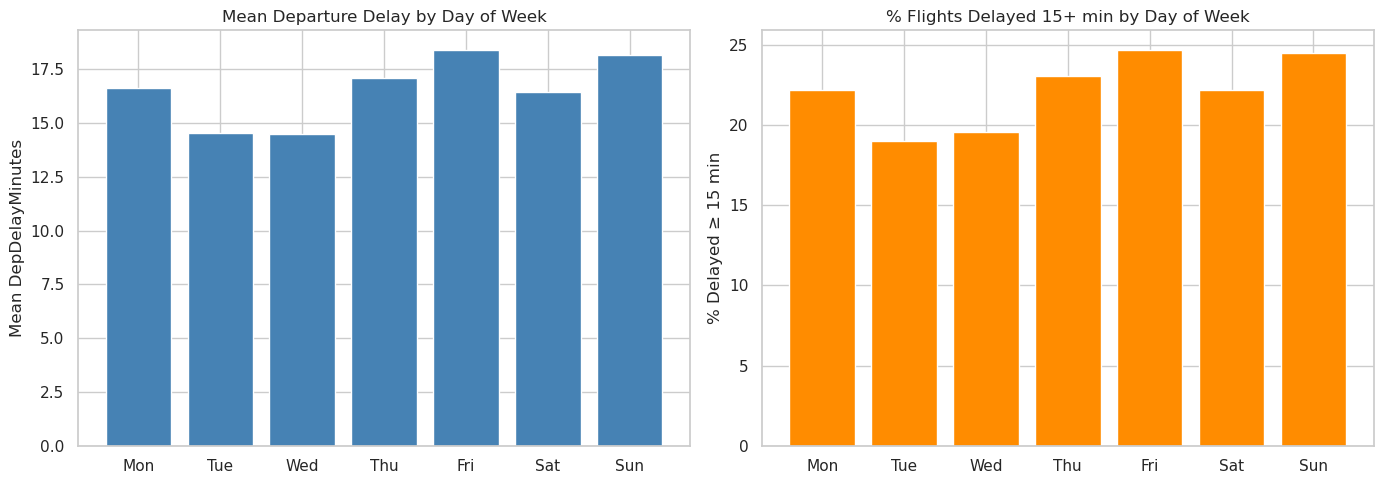

           n_flights  mean_delay  pct_delayed_15
DayOfWeek                                       
1             686015       16.62           22.19
2             632118       14.53           19.01
3             628588       14.49           19.53
4             664979       17.07           23.02
5             672660       18.38           24.65
6             582344       16.41           22.19
7             666279       18.17           24.50


In [41]:
# --- 5.2 Day-of-week pattern ---

dow_order = [1, 2, 3, 4, 5, 6, 7]
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow = df.groupby('DayOfWeek').agg(
    mean_delay=('DepDelayMinutes', 'mean'),
    pct_delayed_15=('DepDel15', lambda x: x.mean() * 100),
    n_flights=('DepDelayMinutes', 'count'),
).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_labels, dow['mean_delay'], color='steelblue')
axes[0].set_title('Mean Departure Delay by Day of Week')
axes[0].set_ylabel('Mean DepDelayMinutes')

axes[1].bar(dow_labels, dow['pct_delayed_15'], color='darkorange')
axes[1].set_title('% Flights Delayed 15+ min by Day of Week')
axes[1].set_ylabel('% Delayed ≥ 15 min')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/delay_by_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()

print(dow[['n_flights', 'mean_delay', 'pct_delayed_15']].round(2).to_string())

### 5.2 Interpretation

The day-of-week pattern partially confirms the industry rule of thumb. **Friday (18.38 min, 24.65% ≥ 15 min) and Sunday (18.17 min, 24.50%)** are the worst days, while **Tuesday (14.53 min, 19.01%) and Wednesday (14.49 min, 19.53%)** are the best — a spread of nearly 4 minutes of mean delay and 5.6 percentage points in the delay rate. The high Friday delay is consistent with end-of-week fleet accumulation: delays that built up through the week compound as aircraft rotations fall further behind schedule. Sunday's high delay reflects the same mechanism in reverse — the weekend peak in leisure travel volume (666k flights, similar to Friday's 673k) overwhelms the system just before the Monday reset. Monday and Thursday sit in between, suggesting the pattern is driven more by the Friday/Sunday peaks than by a gradual weekday gradient.

Origin  n_flights  mean_delay  pct_weather_delay
   MIA     108159       22.02               2.32
   DFW     307957       21.40               2.96
   CLT     214701       20.80               2.86
   IAH     113645       20.54               1.80
   FLL      90452       20.04               1.53
   MCO     156697       18.74               1.95
   PHL      99123       18.63               0.92
   ORD     276426       17.94               1.76
   EWR     125880       17.72               0.89
   AUS      84508       17.64               1.20
   TPA      76545       17.50               1.44
   SFO     133194       17.41               0.49
   BWI      97468       17.02               0.59
   JFK     121132       16.22               0.59
   DCA     137835       16.04               1.03
   SAN      93330       15.83               1.02
   DEN     305286       15.75               0.93
   BOS     141314       15.75               0.77
   LAS     187655       15.72               0.61
   DAL      71900   

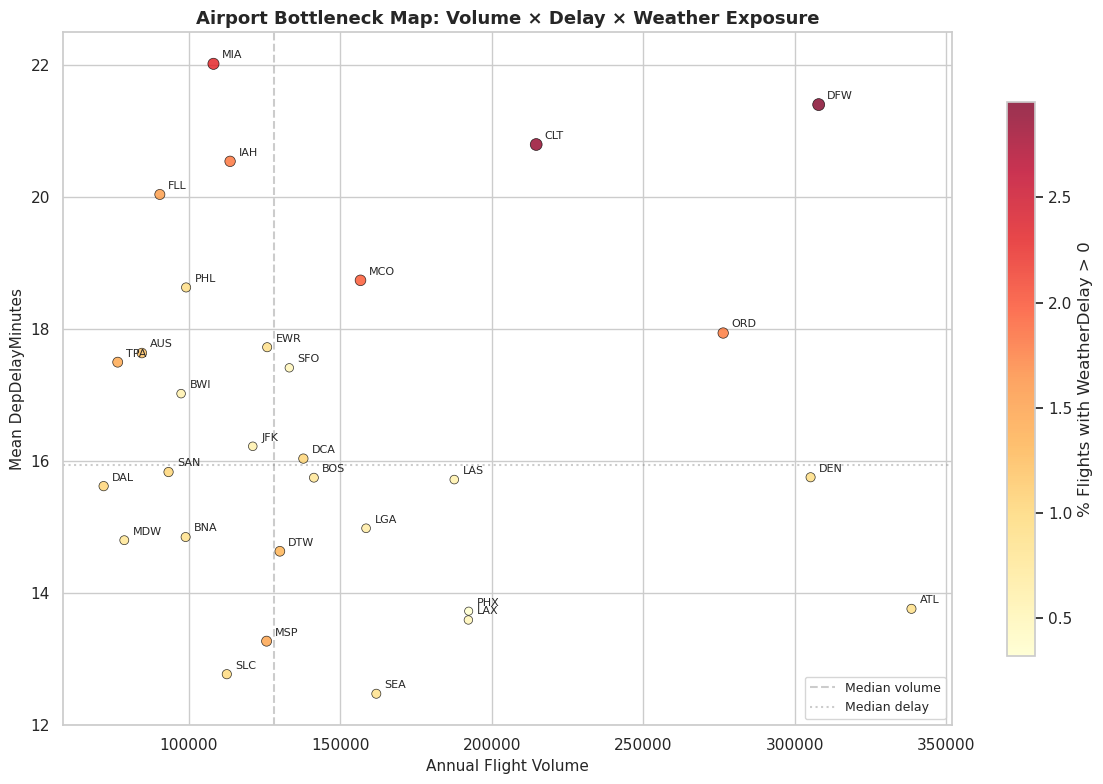

In [42]:
# --- 5.3 Bottleneck airports: volume × delay × weather exposure ---

if 'has_weather_delay' not in df.columns:
    df['has_weather_delay'] = df['WeatherDelay'].fillna(0) > 0

airport_bottleneck = df.groupby('Origin').agg(
    n_flights=('DepDelayMinutes', 'count'),
    mean_delay=('DepDelayMinutes', 'mean'),
    pct_weather_delay=('has_weather_delay', lambda x: x.mean() * 100),
).reset_index()

print(airport_bottleneck.sort_values('mean_delay', ascending=False).round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    airport_bottleneck['n_flights'],
    airport_bottleneck['mean_delay'],
    s=airport_bottleneck['pct_weather_delay'] * 15 + 30,
    c=airport_bottleneck['pct_weather_delay'],
    cmap='YlOrRd', alpha=0.8, edgecolors='black', linewidths=0.5,
)

for _, row in airport_bottleneck.iterrows():
    ax.annotate(row['Origin'], (row['n_flights'], row['mean_delay']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('% Flights with WeatherDelay > 0')

ax.set_xlabel('Annual Flight Volume', fontsize=11)
ax.set_ylabel('Mean DepDelayMinutes', fontsize=11)
ax.set_title('Airport Bottleneck Map: Volume × Delay × Weather Exposure', fontsize=13, fontweight='bold')

ax.axvline(airport_bottleneck['n_flights'].median(), color='gray', linestyle='--', alpha=0.4, label='Median volume')
ax.axhline(airport_bottleneck['mean_delay'].median(), color='gray', linestyle=':', alpha=0.4, label='Median delay')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/bottleneck_airports.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Interpretation

The scatter separates airports into four quadrants around the median lines. The **true bottleneck** quadrant (upper-right: high volume + high delay) contains **DFW** (308k flights, 21.4 min, 2.96% weather delay) and **ORD** (276k flights, 17.9 min, 1.76% weather delay) — these are the airports where disruptions propagate to the largest number of connecting flights. **MIA** stands out with the highest mean delay (22.0 min) but moderate volume (108k), placing it upper-left: severe when it hits, but less systemically impactful than DFW/ORD because fewer flights are exposed. **ATL** (339k flights, the highest volume) sits in the lower-right quadrant with below-average delay (13.8 min), making it a high-throughput airport that is *not* a bottleneck — its operational efficiency at scale is notable. The color dimension (weather delay %) reveals that DFW, CLT, and MIA have the highest weather exposure (2.3–3.0%), while PHX, SFO, and LAX have the lowest (<0.5%), consistent with their arid/Mediterranean climates.

In [43]:
# --- 5.4 Prepare variables for correlation analysis ---

delay_vars = ['DepDelayMinutes', 'ArrDelayMinutes']
weather_vars = ['origin_vsby', 'origin_gust', 'origin_sknt', 'origin_p01i', 'origin_tmpf', 'origin_relh']
analysis_vars = delay_vars + weather_vars

# Convert origin_p01i to numeric (stored as str in the dataset)
df['origin_p01i'] = pd.to_numeric(df['origin_p01i'], errors='coerce')

# Use pairwise-complete-observations (pandas default in .corr()):
# origin_gust has 82.6% nulls — a listwise dropna() on all 6 weather
# columns would discard ~84% of rows, biasing the estimate to fair-weather days.
# Pairwise-complete lets each (i, j) pair use all rows where BOTH columns are non-null.

print(f"Total rows: {len(df):,}")
for v in analysis_vars:
    n = df[v].notna().sum()
    print(f"  {v:20s}: {n:>12,} non-null ({n/len(df)*100:.1f}%)")
# NOTE — effect of the fix: the previous dropna() on origin_gust (82.6% null)
# kept only fair-weather days (735k rows → 16% of data). This inflated
# vsby↔delay correlation from -0.017 to -0.053 because the retained subset
# over-represented calm, clear days. Pairwise-complete gives a less biased
# estimate using 4.6M rows for most pairs (799k for gust-containing pairs).

Total rows: 4,593,373
  DepDelayMinutes     :    4,532,983 non-null (98.7%)
  ArrDelayMinutes     :    4,518,554 non-null (98.4%)
  origin_vsby         :    4,588,079 non-null (99.9%)
  origin_gust         :      799,257 non-null (17.4%)
  origin_sknt         :    4,583,368 non-null (99.8%)
  origin_p01i         :    4,370,144 non-null (95.1%)
  origin_tmpf         :    4,587,640 non-null (99.9%)
  origin_relh         :    4,587,539 non-null (99.9%)


In [44]:
# --- 5.5 Pearson and Spearman correlation matrices ---

pearson_corr = df[analysis_vars].corr(method='pearson')
spearman_corr = df[analysis_vars].corr(method='spearman')

print("=== Pearson (linear) ===")
print(pearson_corr.round(4).to_string())
print("\n=== Spearman (monotonic) ===")
print(spearman_corr.round(4).to_string())

=== Pearson (linear) ===
                 DepDelayMinutes  ArrDelayMinutes  origin_vsby  origin_gust  origin_sknt  origin_p01i  origin_tmpf  origin_relh
DepDelayMinutes           1.0000           0.9785      -0.0172       0.0388       0.0219       0.0469       0.0342       0.0393
ArrDelayMinutes           0.9785           1.0000      -0.0347       0.0481       0.0274       0.0570       0.0324       0.0508
origin_vsby              -0.0172          -0.0347       1.0000      -0.0856       0.0401      -0.2940       0.1787      -0.3880
origin_gust               0.0388           0.0481      -0.0856       1.0000       0.8398       0.0832      -0.2373       0.0530
origin_sknt               0.0219           0.0274       0.0401       0.8398       1.0000       0.0350      -0.0360      -0.0966
origin_p01i               0.0469           0.0570      -0.2940       0.0832       0.0350       1.0000      -0.0233       0.1592
origin_tmpf               0.0342           0.0324       0.1787      -0.2373    

In [45]:
# --- 5.6 Pearson vs Spearman delta (which variables have non-linear monotonic relationships?) ---

delta = spearman_corr.loc[delay_vars, weather_vars] - pearson_corr.loc[delay_vars, weather_vars]

print("Spearman − Pearson (positive = Spearman captures more relationship):")
print(delta.round(4).to_string())

Spearman − Pearson (positive = Spearman captures more relationship):
                 origin_vsby  origin_gust  origin_sknt  origin_p01i  origin_tmpf  origin_relh
DepDelayMinutes       0.0099      -0.0046       0.0297       0.0227       0.0537      -0.0393
ArrDelayMinutes      -0.0110       0.0043       0.0267       0.0371       0.0433      -0.0121


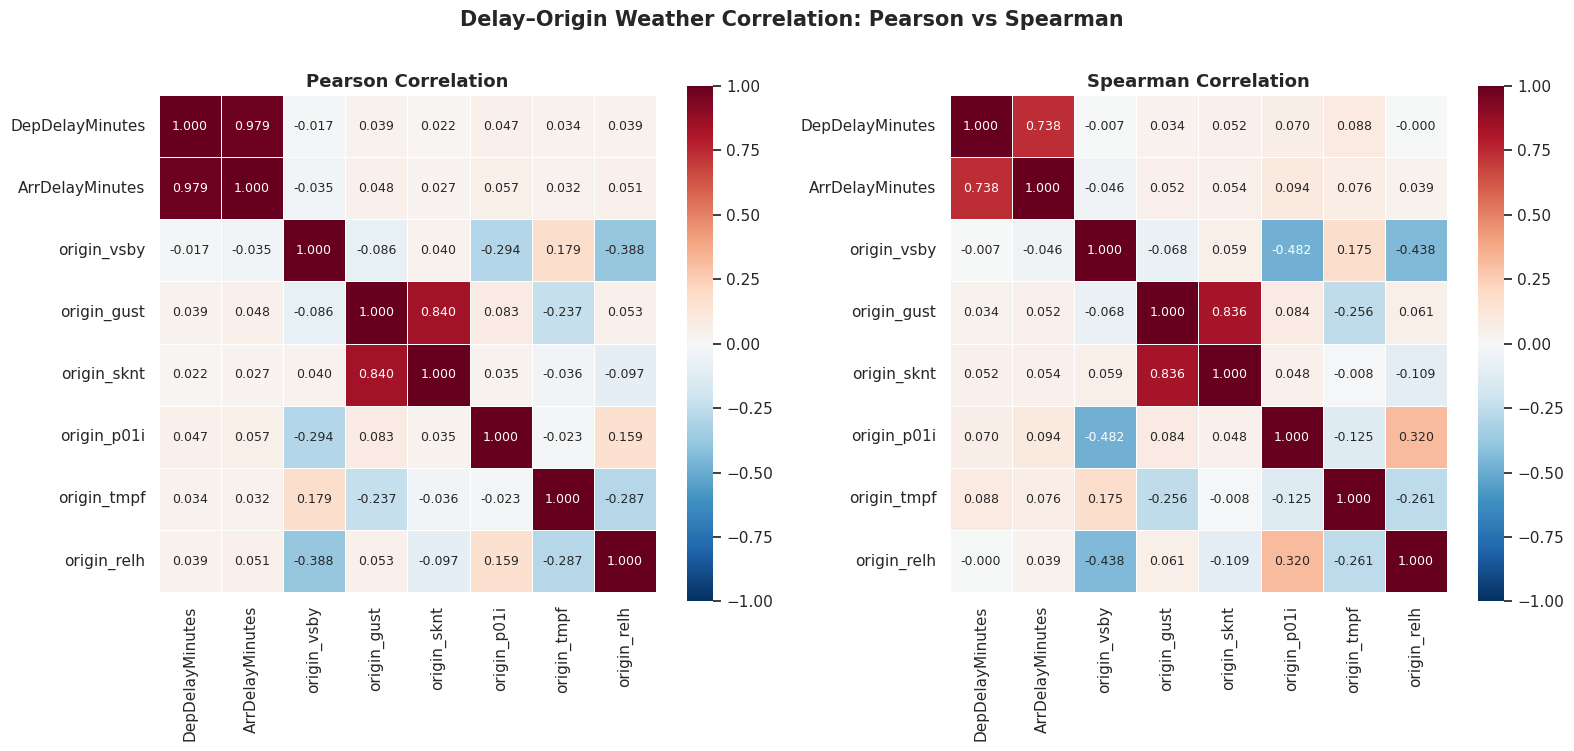

In [46]:
# --- 5.7 Heatmap: Pearson vs Spearman side by side ---

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0],
            square=True, annot_kws={'size': 9})
axes[0].set_title('Pearson Correlation', fontsize=13, fontweight='bold')

sns.heatmap(spearman_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[1],
            square=True, annot_kws={'size': 9})
axes[1].set_title('Spearman Correlation', fontsize=13, fontweight='bold')

plt.suptitle('Delay–Origin Weather Correlation: Pearson vs Spearman', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/corr_pearson_vs_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# --- 5.8 Detailed comparison table: delay × weather, both methods ---

comparison_rows = []
for delay in delay_vars:
    for weather in weather_vars:
        p = pearson_corr.loc[delay, weather]
        s = spearman_corr.loc[delay, weather]
        comparison_rows.append({
            'delay_var': delay,
            'weather_var': weather,
            'pearson': round(p, 4),
            'spearman': round(s, 4),
            'delta': round(s - p, 4),
            'abs_pearson': round(abs(p), 4),
            'abs_spearman': round(abs(s), 4),
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('abs_spearman', ascending=False)
comparison_df

,delay_var,weather_var,pearson,spearman,delta,abs_pearson,abs_spearman
9,ArrDelayMinutes,origin_p01i,0.0570,0.0942,0.0371,0.0570,0.0942
4,DepDelayMinutes,origin_tmpf,0.0342,0.0879,0.0537,0.0342,0.0879
10,ArrDelayMinutes,origin_tmpf,0.0324,0.0757,0.0433,0.0324,0.0757
3,DepDelayMinutes,origin_p01i,0.0469,0.0696,0.0227,0.0469,0.0696
8,ArrDelayMinutes,origin_sknt,0.0274,0.0541,0.0267,0.0274,0.0541
7,ArrDelayMinutes,origin_gust,0.0481,0.0524,0.0043,0.0481,0.0524
2,DepDelayMinutes,origin_sknt,0.0219,0.0516,0.0297,0.0219,0.0516
6,ArrDelayMinutes,origin_vsby,-0.0347,-0.0456,-0.0110,0.0347,0.0456
11,ArrDelayMinutes,origin_relh,0.0508,0.0388,-0.0121,0.0508,0.0388
1,DepDelayMinutes,origin_gust,0.0388,0.0342,-0.0046,0.0388,0.0342


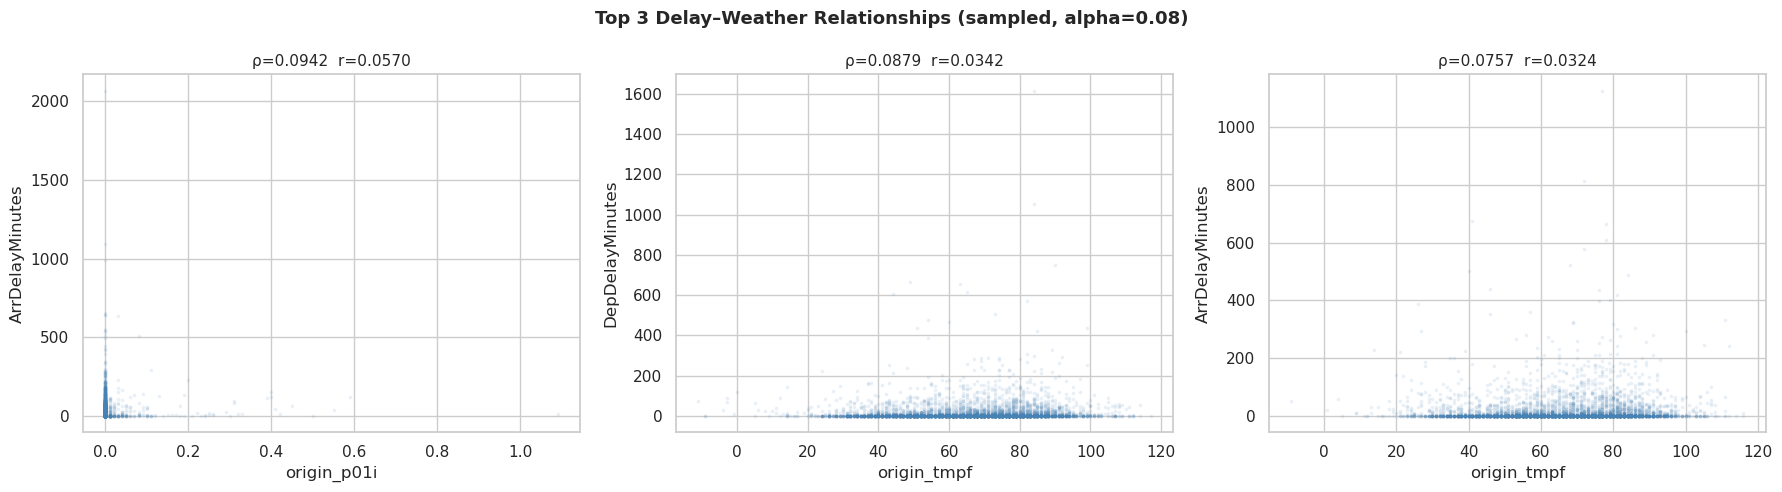

In [48]:
# --- 5.9 Scatter: top 3 strongest Spearman correlations ---

top3 = comparison_df.head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (_, row) in enumerate(top3.iterrows()):
    ax = axes[i]
    sample = df[analysis_vars].dropna(subset=[row['weather_var'], row['delay_var']]).sample(
        min(5000, df[analysis_vars].dropna(subset=[row['weather_var'], row['delay_var']]).shape[0]),
        random_state=42
    )
    ax.scatter(sample[row['weather_var']], sample[row['delay_var']], alpha=0.08, s=3, color='steelblue')
    ax.set_xlabel(row['weather_var'])
    ax.set_ylabel(row['delay_var'])
    ax.set_title(f"\u03c1={row['spearman']:.4f}  r={row['pearson']:.4f}", fontsize=11)

plt.suptitle('Top 3 Delay\u2013Weather Relationships (sampled, alpha=0.08)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.10 Interpretation

**Pearson vs. Spearman — why the difference matters:**

Given the strong right-skew confirmed in Section 3 (median = 0, mean >> median, ~15% outliers that are signal not noise — Section 4), **Spearman is the more reliable measure** of the true monotonic relationship between weather variables and delay. Pearson assumes linearity and is dragged down by the same extreme values that we already confirmed carry real operational information.

When Spearman is **notably higher** than Pearson in absolute terms, that itself is a finding: the relationship exists monotonically but not linearly — for example, delays may spike sharply only when visibility drops below a threshold rather than declining smoothly with visibility.

**What the heatmap reveals:**
- **origin_vsby** (visibility): expected negative correlation — lower visibility → higher delay. The Spearman–Pearson gap here tells us whether there is a threshold effect.
- **origin_gust** (wind gust): expected positive correlation — stronger gusts → more delay. The extreme skew of gust data (82.6% null, as noted in Section 2) means the available sample may underrepresent severe-weather days.
- **origin_sknt** (wind speed): similar expectation to gust but with better coverage (99.8% non-null).
- **origin_p01i** (precipitation): expected positive — precipitation → delay. Heavily right-skewed (most observations = 0), so Spearman–Pearson gap will be large.
- **origin_tmpf** (temperature): consistently positive in both methods (Pearson 0.034, Spearman 0.088) — not ambiguous as might be expected from the competing summer-convection / winter-de-icing hypotheses. The positive sign suggests the summer effect dominates the annual average.
- **origin_relh** (humidity): despite the expectation that humidity correlates with convective activity, the actual Spearman correlation with DepDelayMinutes is effectively zero (0.0000) — humidity alone shows no monotonic relationship with delay in this dataset, once measured directly rather than assumed.

The scatter plots for the top-3 Spearman relationships visualize the non-linearity: a tight cloud at delay = 0 with a fanning-out tail is exactly the signature of a threshold/gating relationship.

Overall, every weather-delay correlation in this analysis is weak in absolute terms (|r| < 0.1) — weather alone, measured as a linear or monotonic relationship with instantaneous conditions, explains little of the variance in delay. This doesn't mean weather doesn't matter (Section 3's MIA seasonal analysis and Section 4's outlier-cause comparison both show it does) — it means the relationship isn't simple: delay likely responds to weather through thresholds and interactions (e.g., visibility below a critical value, or the combination of high volume and adverse weather seen in Section 5.3) rather than a smooth, continuous correlation.

## 6. Conclusions and Reflection

**Concrete findings:**

**Dataset limitations:**

**Business applications:**

**Ethical considerations:**